<a href="https://colab.research.google.com/github/Sanathcharan/Data-Science-ExcelR/blob/main/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('banking_dataset.csv')
df

,customer_age,account_balance,annual_income,loan_amount,loan_duration_months,num_of_credit_cards,credit_card_utilization,monthly_salary,num_of_loans,num_of_defaults,...,insurance_amount,spending_score,digital_transactions_ratio,mobile_banking_usage_hours,branch_visits_per_month,internet_banking_logins,loan_interest_rate,customer_satisfaction_score,risk_factor,bank_profit
0,56,17871.07,1131740.96,409401.23,51,3,0.84,54136.15,2,2,...,128309.65,98.05,0.29,3.63,8,6,6.44,6.68,0.75,494405.22
1,69,54069.27,600090.95,188667.47,31,1,0.51,63632.00,3,2,...,62273.87,0.33,0.89,6.29,6,21,10.82,2.43,0.11,268619.57
2,46,34872.99,756171.18,206035.43,13,3,0.53,63740.55,0,0,...,91142.90,12.02,0.75,5.35,9,5,11.98,3.57,0.79,356441.45
3,32,21554.93,933147.71,318767.03,11,2,0.56,59817.85,1,2,...,115780.27,54.69,0.93,10.51,0,5,6.37,2.89,0.03,373216.34
4,60,37068.54,345408.57,219029.55,29,0,0.17,49422.27,2,1,...,85623.14,95.59,0.69,9.11,3,13,8.60,5.86,0.44,328103.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,58390.65,1063315.17,81548.24,44,1,0.26,45809.55,1,2,...,126001.07,55.65,0.58,12.21,1,1,8.39,2.88,0.76,384050.41
996,64,32250.16,365348.55,342287.23,54,0,0.24,66996.69,2,1,...,117818.80,84.13,0.29,6.40,4,7,7.82,1.82,0.07,82503.90
997,62,41250.83,873229.66,360907.95,49,2,0.48,58192.38,1,2,...,88071.53,20.69,0.10,4.68,5,19,7.44,4.70,0.49,385545.47
998,35,64447.63,548534.79,225825.55,59,0,0.89,63468.87,3,0,...,117764.24,98.92,0.91,6.49,0,10,9.63,4.16,0.32,258298.33


In [ ]:
df.head()

,customer_age,account_balance,annual_income,loan_amount,loan_duration_months,num_of_credit_cards,credit_card_utilization,monthly_salary,num_of_loans,num_of_defaults,...,insurance_amount,spending_score,digital_transactions_ratio,mobile_banking_usage_hours,branch_visits_per_month,internet_banking_logins,loan_interest_rate,customer_satisfaction_score,risk_factor,bank_profit
0,56,17871.07,1131740.96,409401.23,51,3,0.84,54136.15,2,2,...,128309.65,98.05,0.29,3.63,8,6,6.44,6.68,0.75,494405.22
1,69,54069.27,600090.95,188667.47,31,1,0.51,63632.00,3,2,...,62273.87,0.33,0.89,6.29,6,21,10.82,2.43,0.11,268619.57
2,46,34872.99,756171.18,206035.43,13,3,0.53,63740.55,0,0,...,91142.90,12.02,0.75,5.35,9,5,11.98,3.57,0.79,356441.45
3,32,21554.93,933147.71,318767.03,11,2,0.56,59817.85,1,2,...,115780.27,54.69,0.93,10.51,0,5,6.37,2.89,0.03,373216.34
4,60,37068.54,345408.57,219029.55,29,0,0.17,49422.27,2,1,...,85623.14,95.59,0.69,9.11,3,13,8.60,5.86,0.44,328103.09


In [ ]:
df.isnull().sum()

,0
customer_age,0
account_balance,0
annual_income,0
loan_amount,0
loan_duration_months,0
num_of_credit_cards,0
credit_card_utilization,0
monthly_salary,0
num_of_loans,0
num_of_defaults,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_age                 1000 non-null   int64  
 1   account_balance              1000 non-null   float64
 2   annual_income                1000 non-null   float64
 3   loan_amount                  1000 non-null   float64
 4   loan_duration_months         1000 non-null   int64  
 5   num_of_credit_cards          1000 non-null   int64  
 6   credit_card_utilization      1000 non-null   float64
 7   monthly_salary               1000 non-null   float64
 8   num_of_loans                 1000 non-null   int64  
 9   num_of_defaults              1000 non-null   int64  
 10  num_of_transactions          1000 non-null   int64  
 11  avg_transaction_value        1000 non-null   float64
 12  loan_to_income_ratio         1000 non-null   float64
 13  credit_score       

In [ ]:
df.shape

(1000, 31)

In [ ]:
df.size

31000

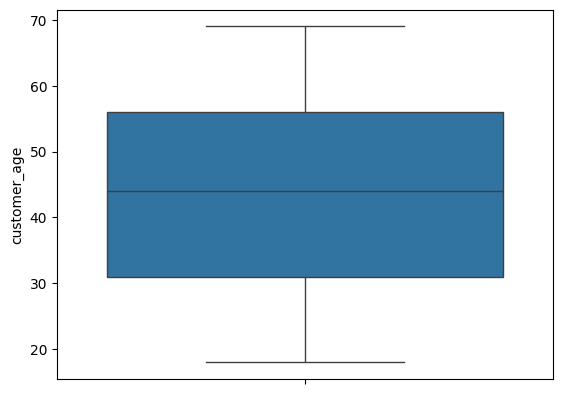

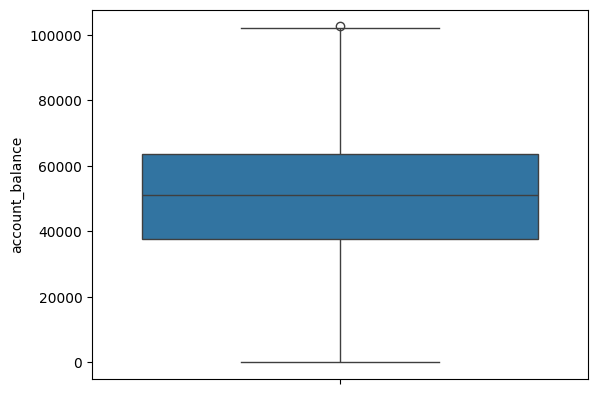

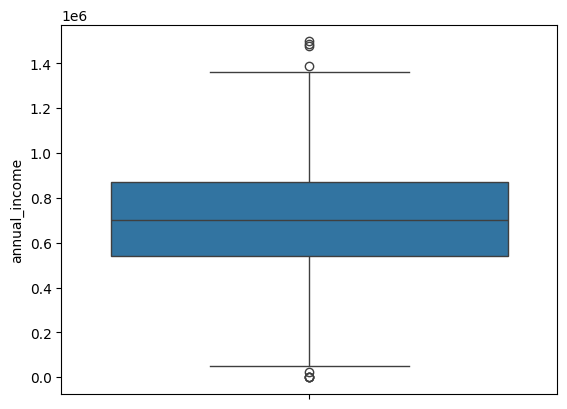

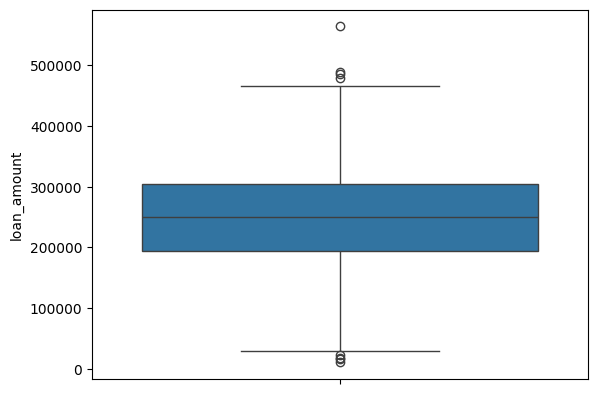

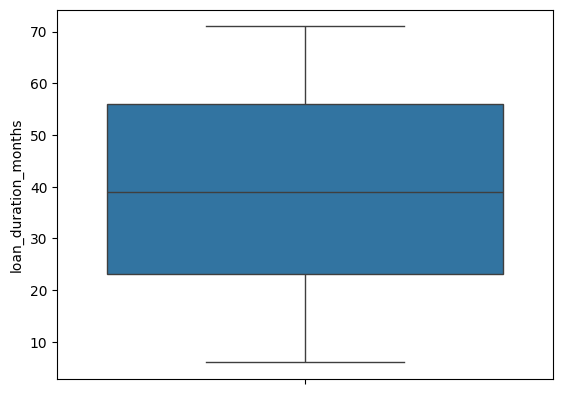

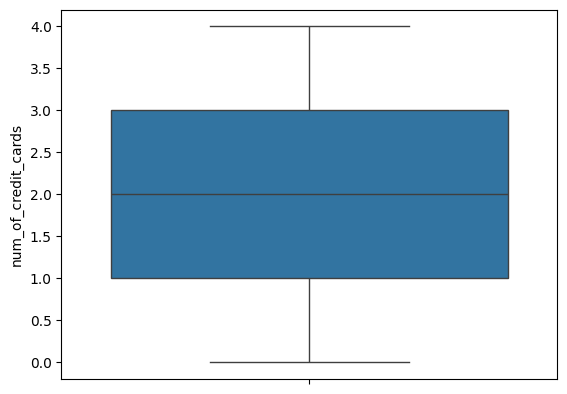

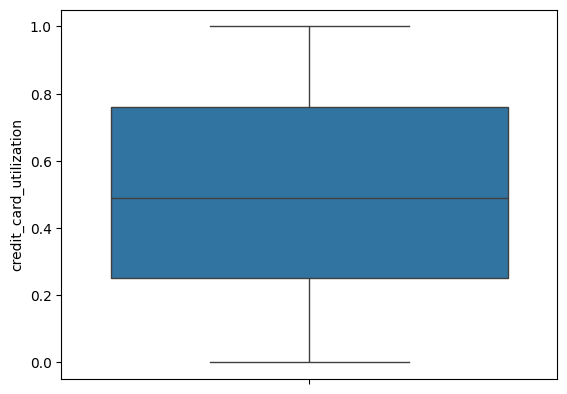

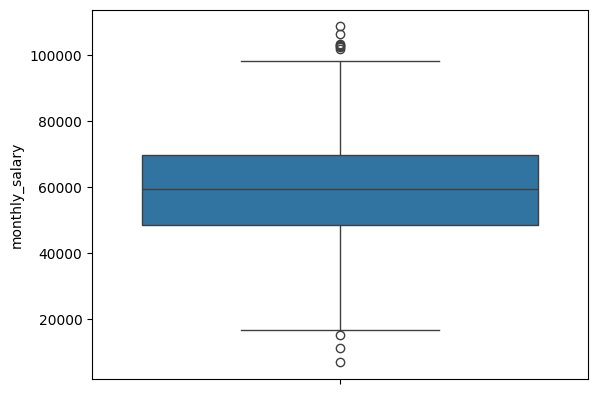

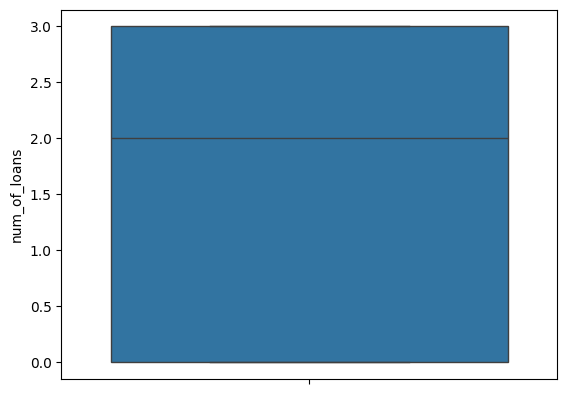

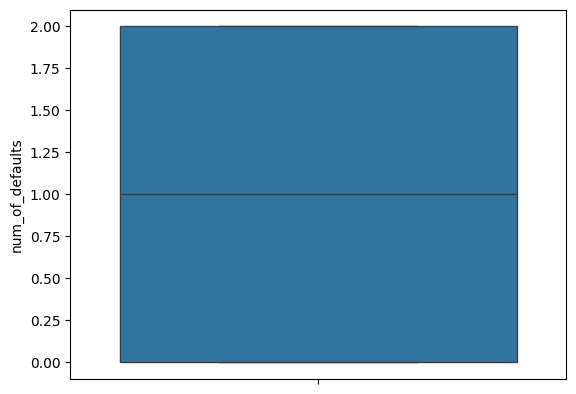

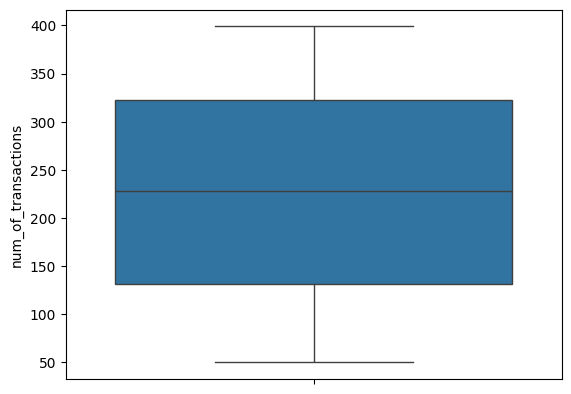

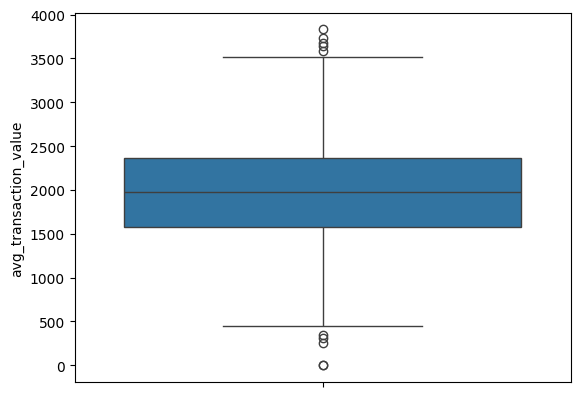

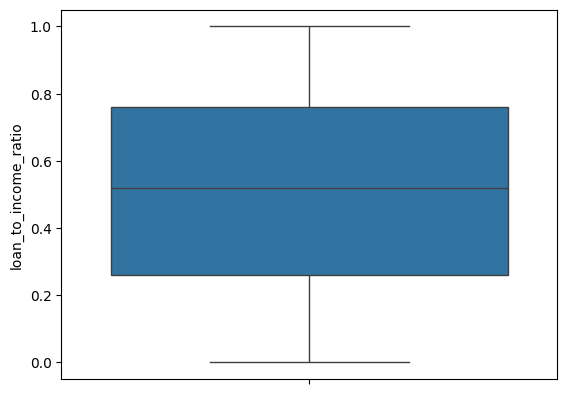

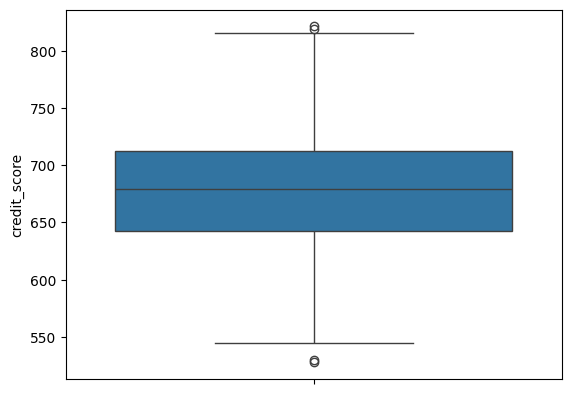

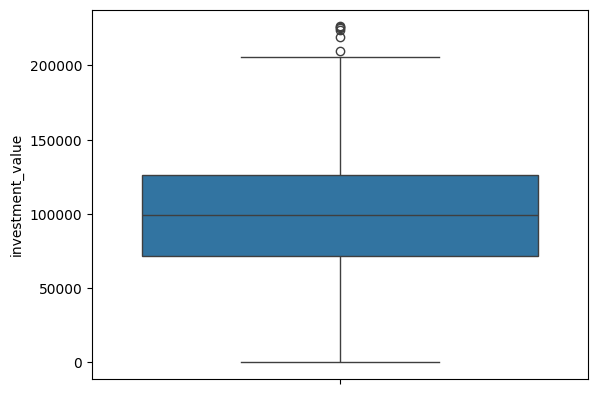

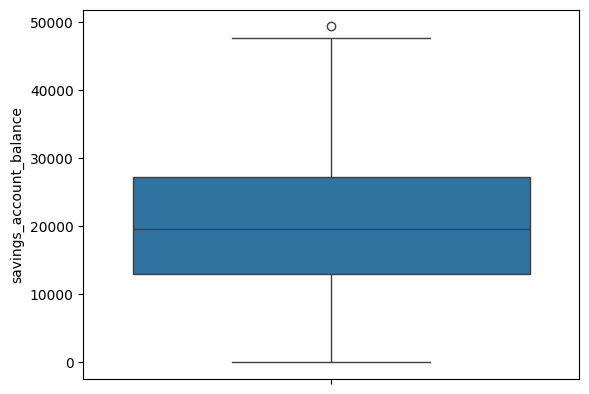

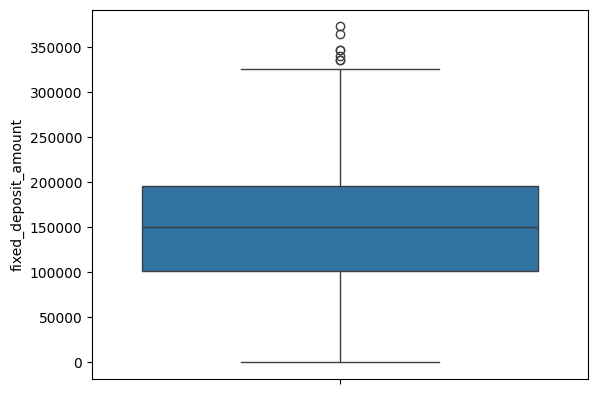

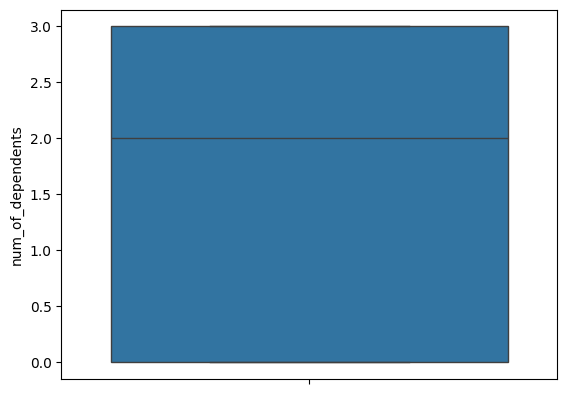

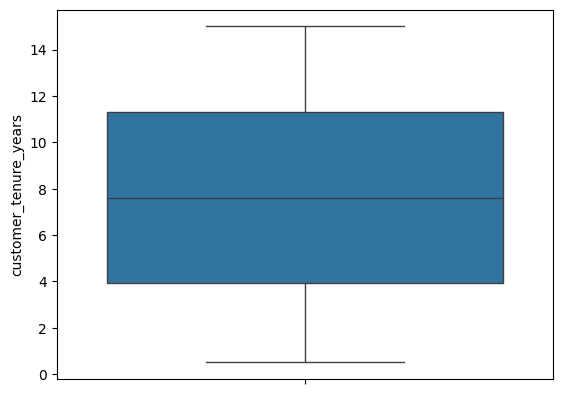

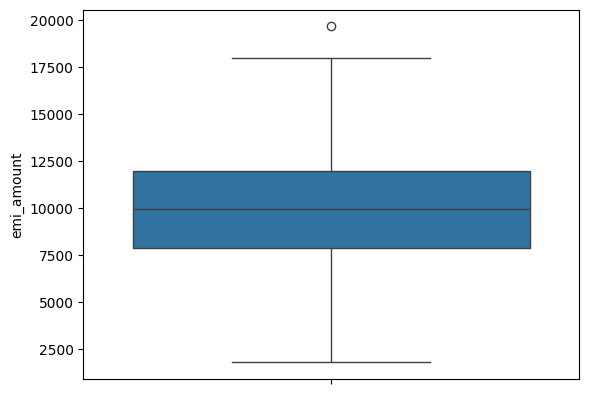

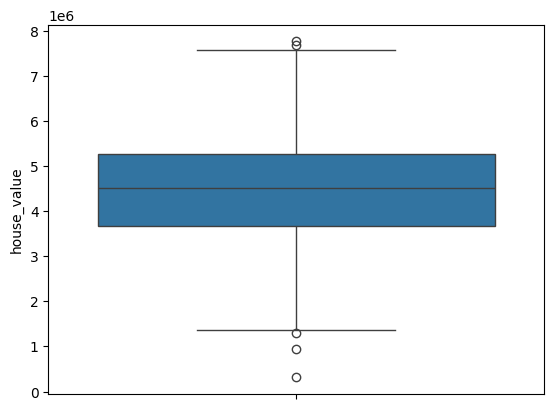

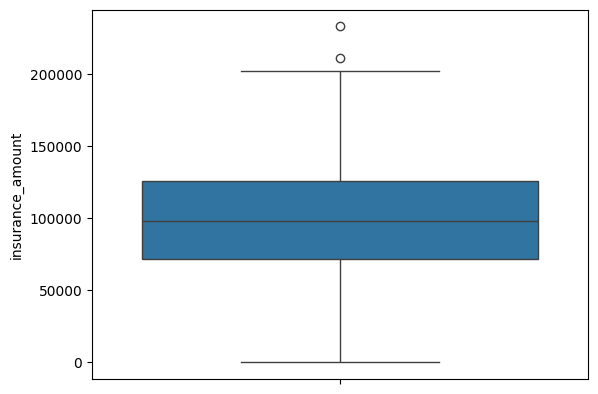

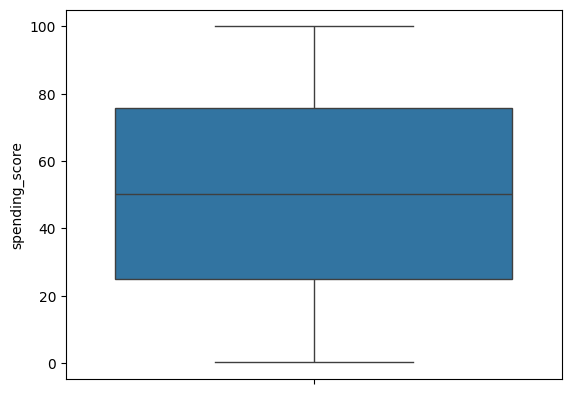

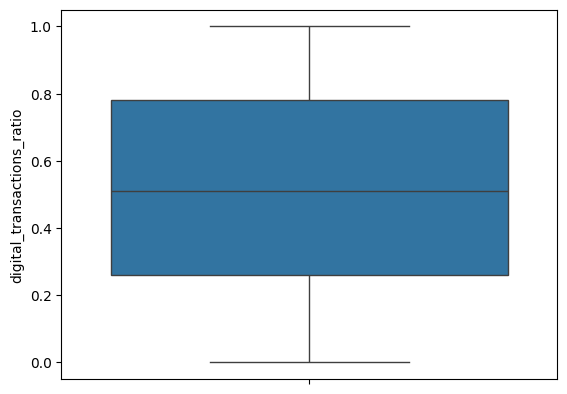

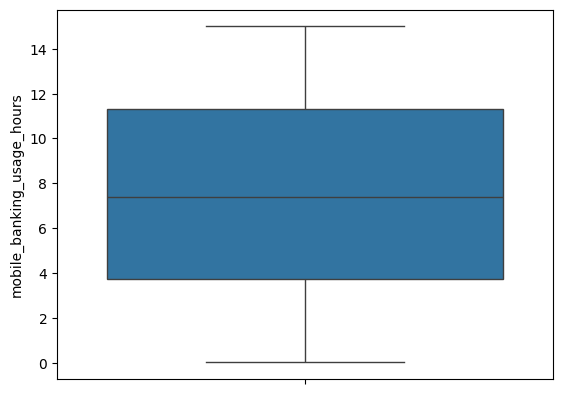

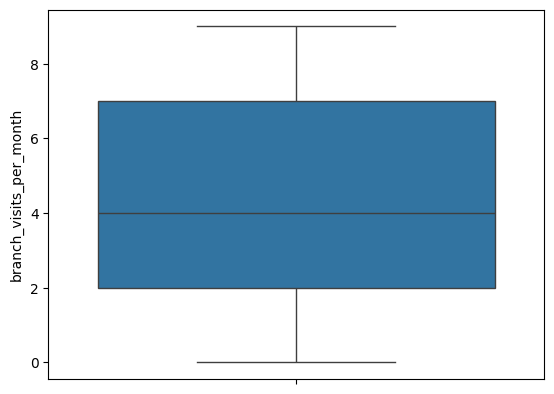

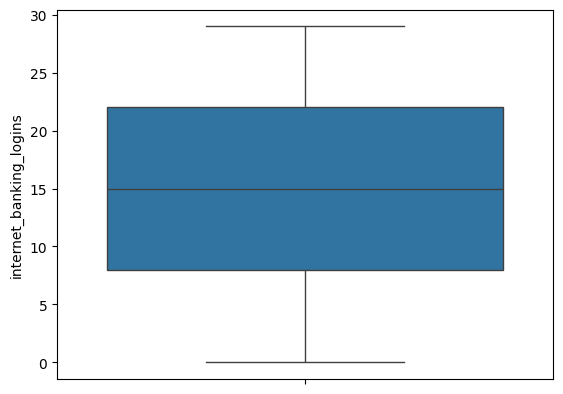

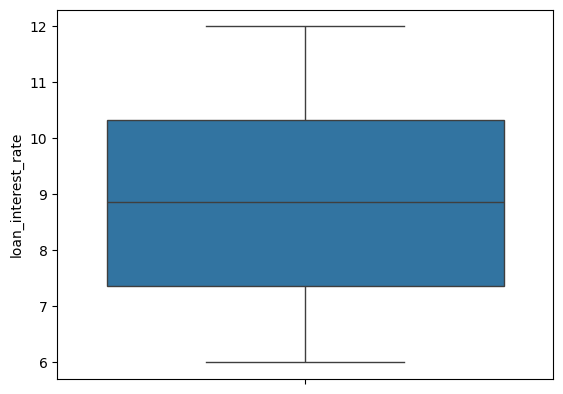

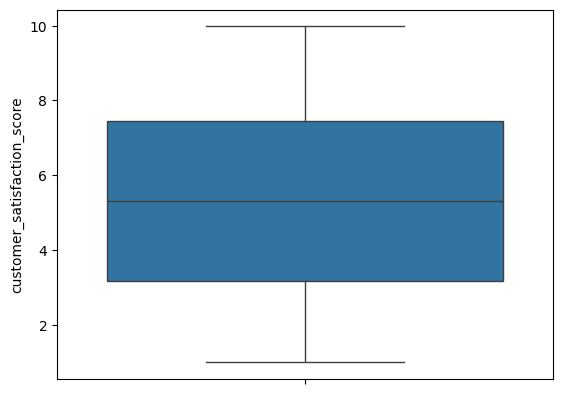

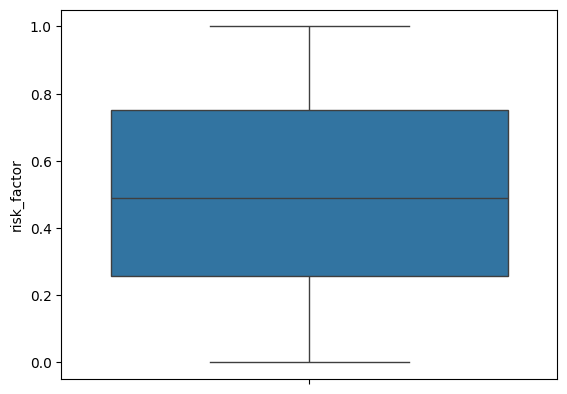

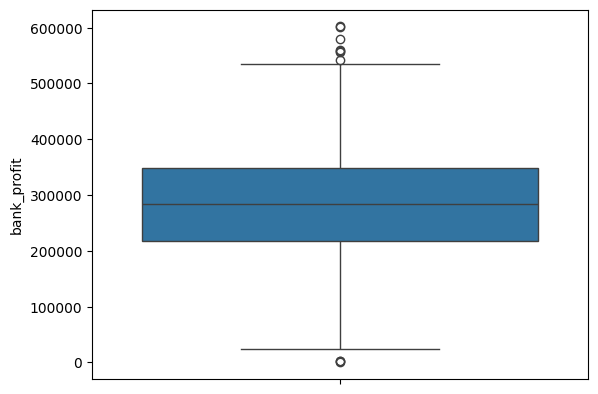

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  sns.boxplot(df[i])
  plt.show()

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  upper=q3+1.5*iqr
  lower=q1-1.5*iqr
  df[i]=df[i].clip(lower,upper)

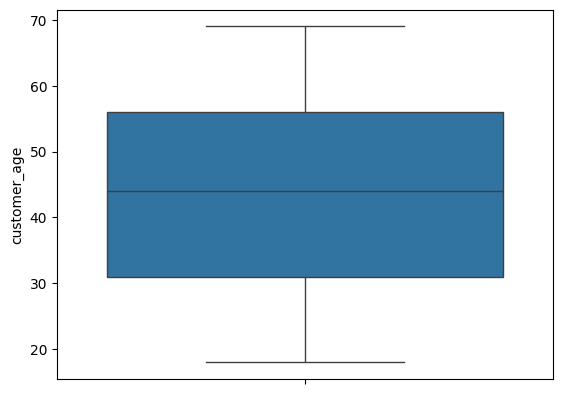

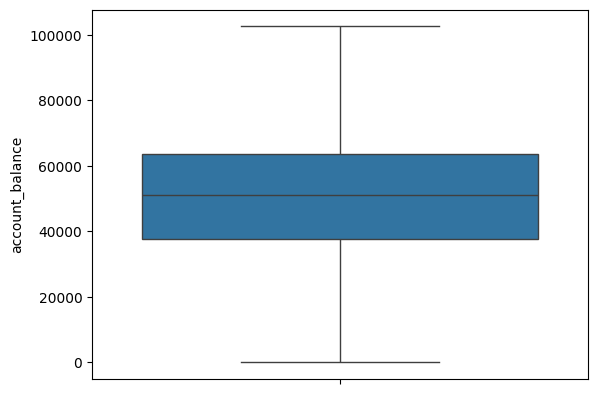

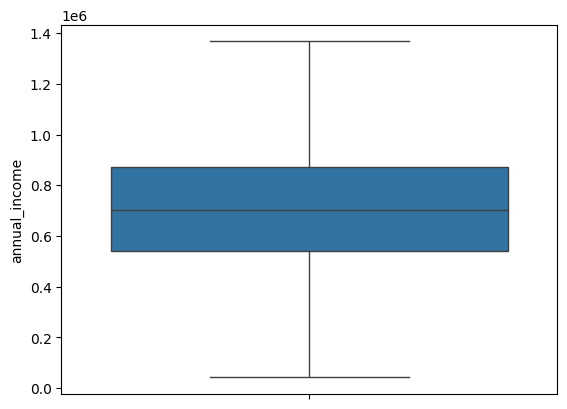

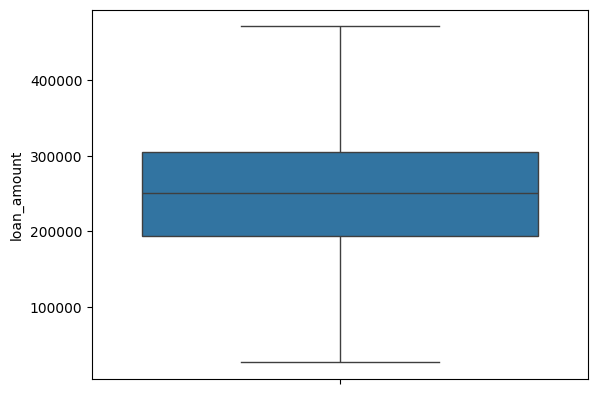

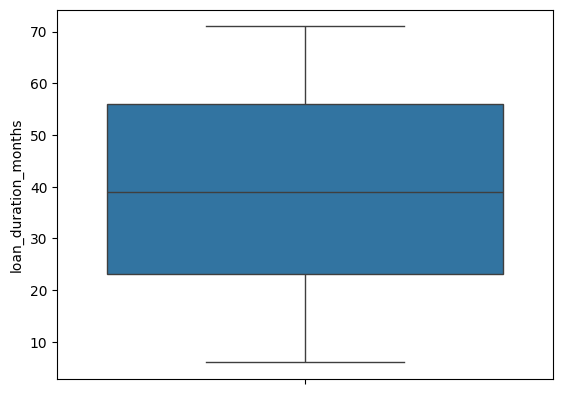

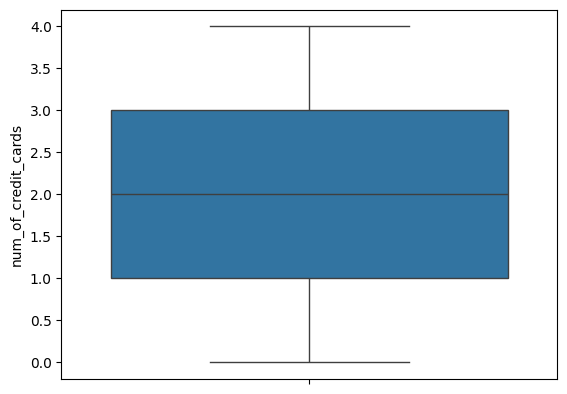

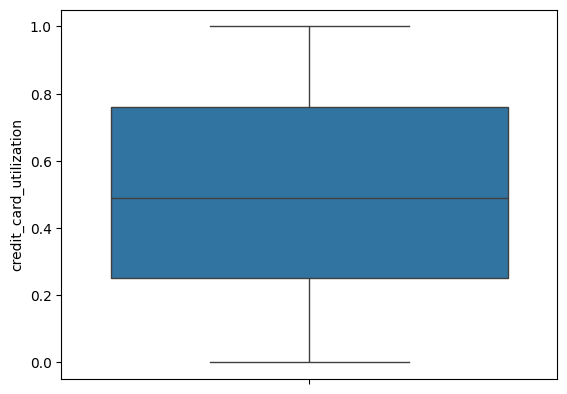

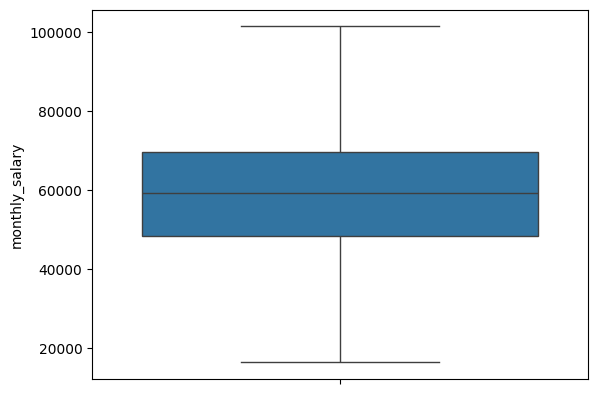

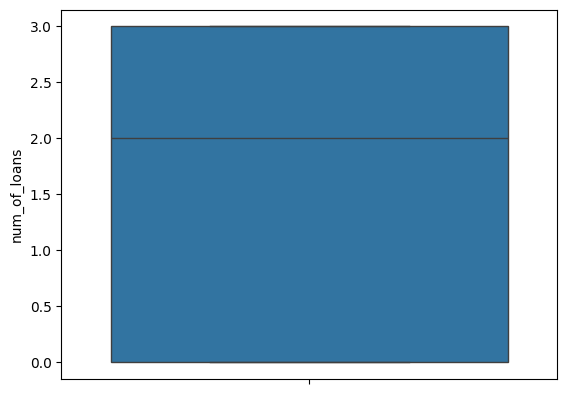

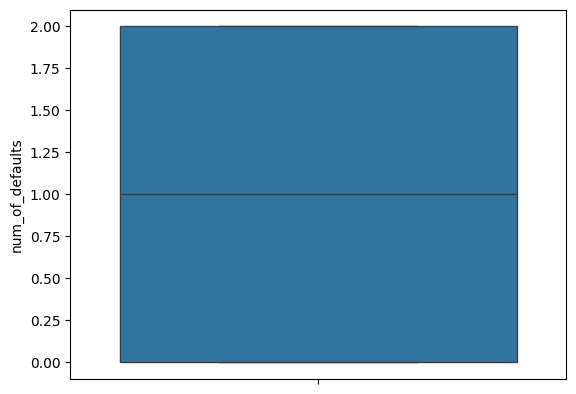

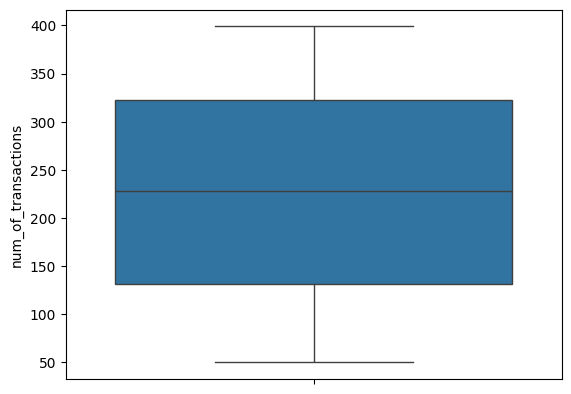

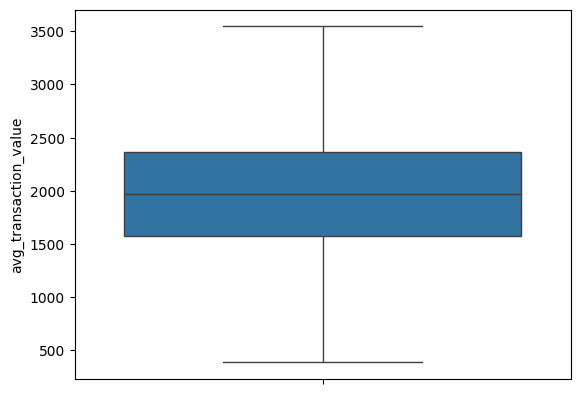

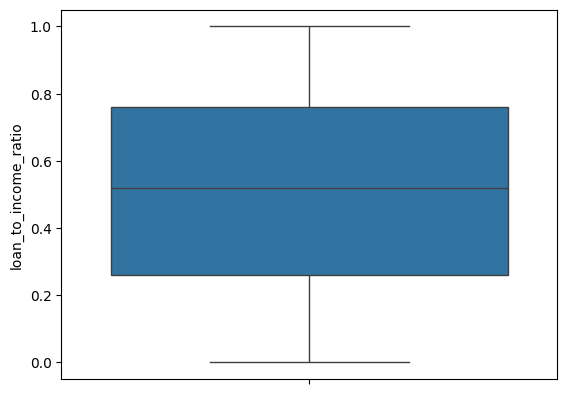

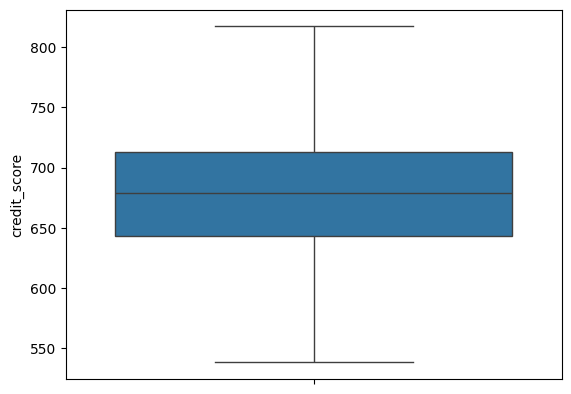

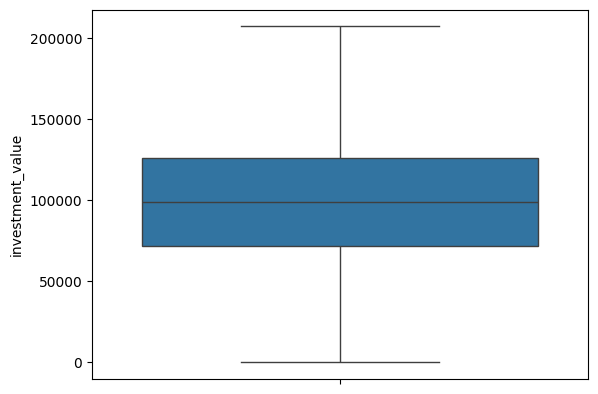

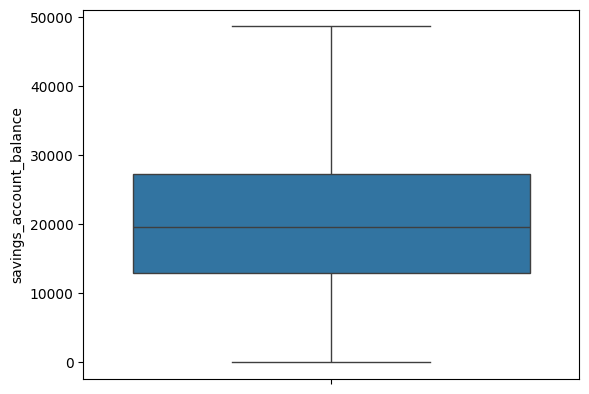

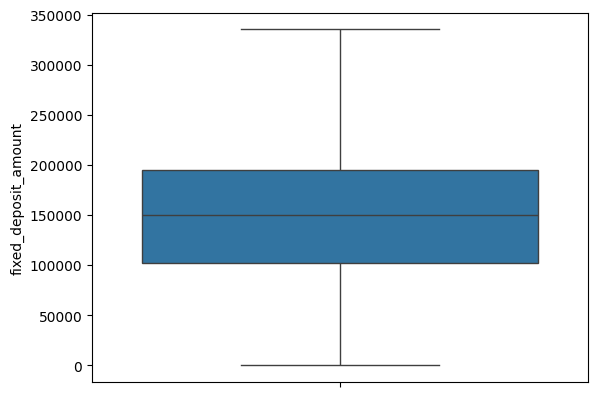

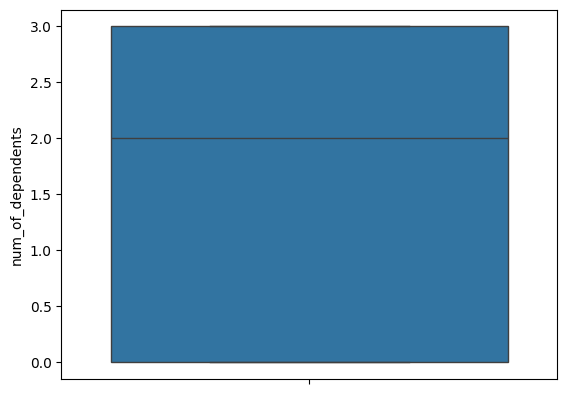

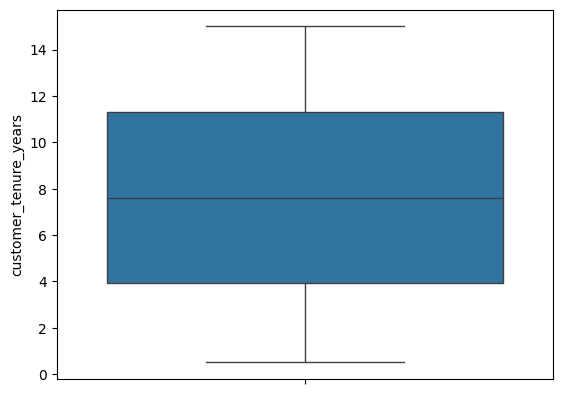

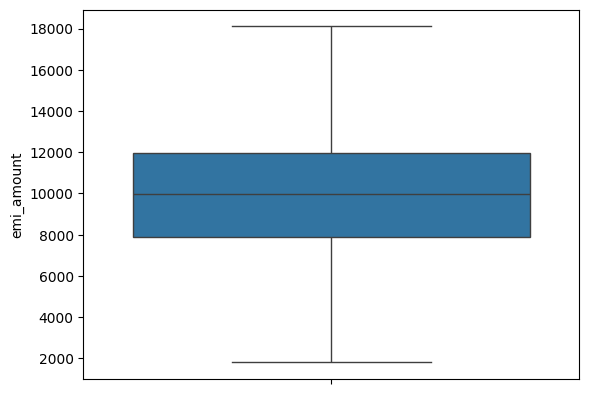

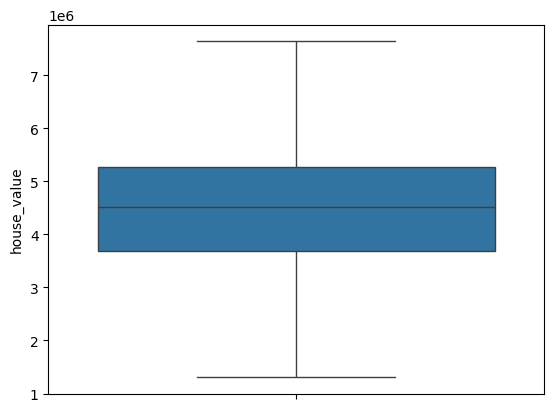

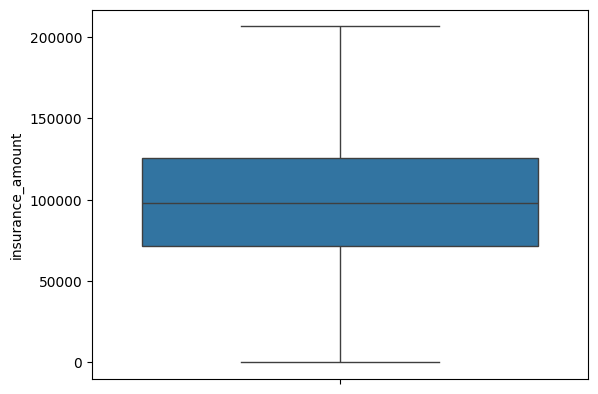

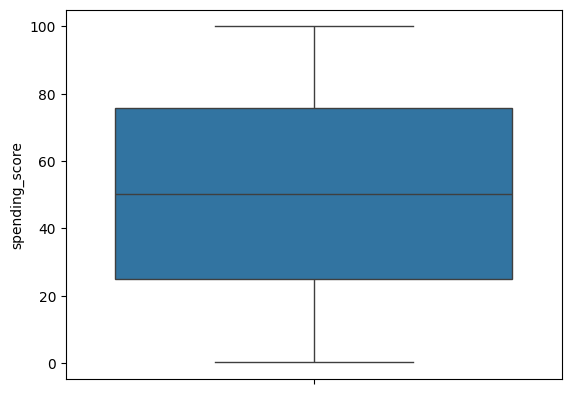

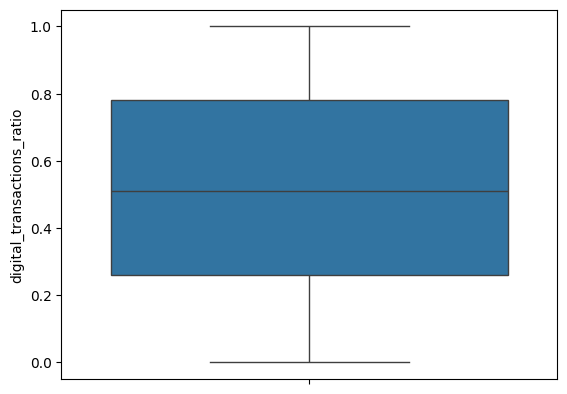

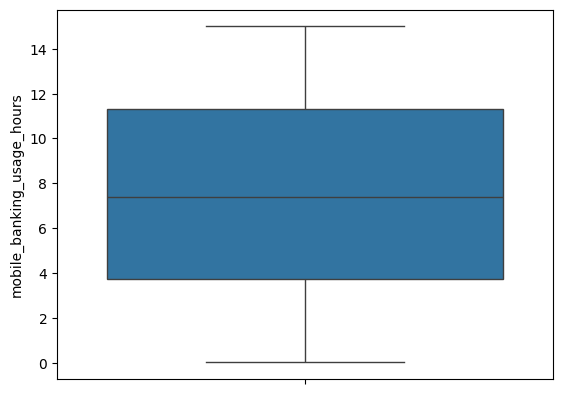

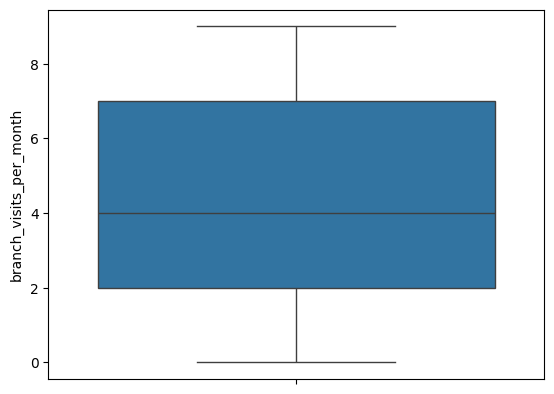

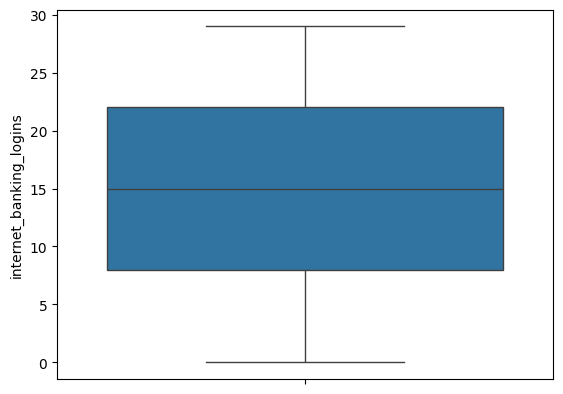

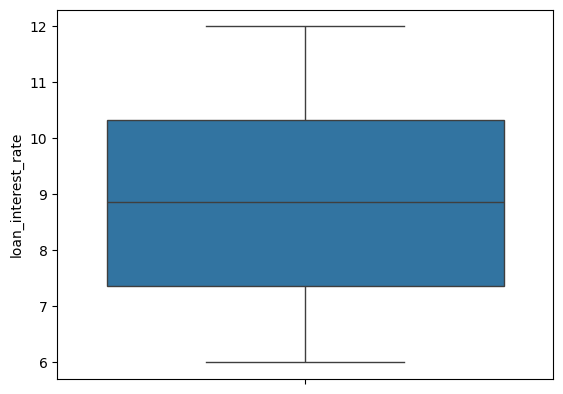

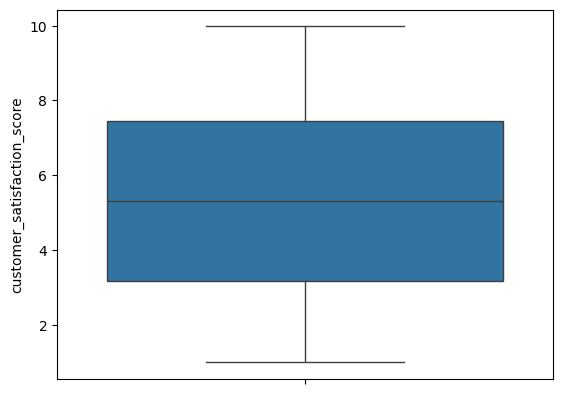

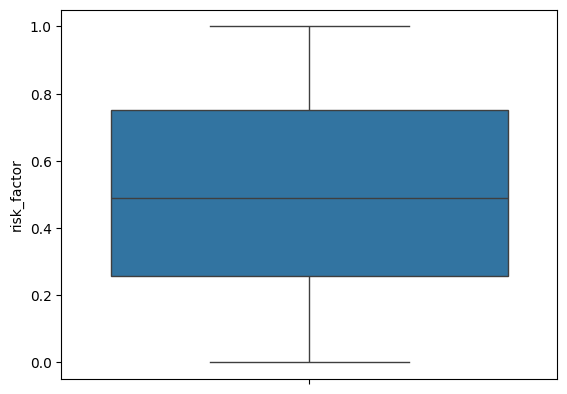

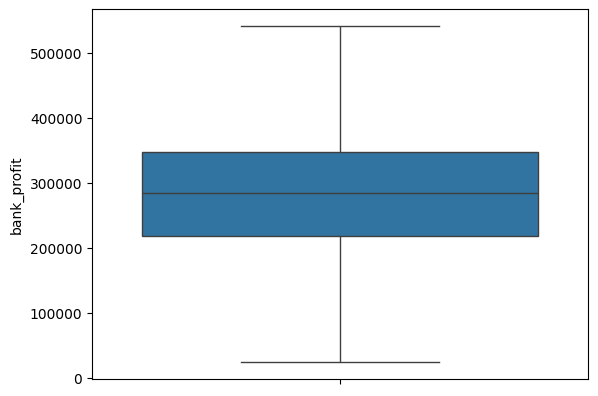

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  sns.boxplot(df[i])
  plt.show()

In [ ]:
x=df.drop(columns=['bank_profit'])
y=df['bank_profit']

In [ ]:
from sklearn .model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=60)

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
pred_train=lr.predict(x_train)
pred_test=lr.predict(x_test)
from sklearn.metrics import r2_score
print("Train R2_score is: ",r2_score(y_train,pred_train))
print("Test R2_score is: ",r2_score(y_test,pred_test))

Train R2_score is:  0.7289004134398243
Test R2_score is:  0.6815692453447113


In [ ]:
from sklearn.linear_model import Lasso
ls=Lasso(alpha=0.5,max_iter=2000)
ls.fit(x_train,y_train)
pred_train=ls.predict(x_train)
pred_test=ls.predict(x_test)
print("Train R2_score is: ",r2_score(y_train,pred_train))
print("Test R2_score is: ",r2_score(y_test,pred_test))

Train R2_score is:  0.728900411694426
Test R2_score is:  0.6815676760083633


In [ ]:
from sklearn.linear_model import LassoCV
ls=LassoCV(cv=10)
ls.fit(x_train,y_train)
pred_train=ls.predict(x_train)
pred_test=ls.predict(x_test)
print("Train R2_score is: ",r2_score(y_train,pred_train))
print("Test R2_score is: ",r2_score(y_test,pred_test))

Train R2_score is:  0.7171424299516802
Test R2_score is:  0.689881601592264


In [ ]:
from sklearn.linear_model import Ridge
rs=Ridge(alpha=0.5,max_iter=2000)
rs.fit(x_train,y_train)
pred_train=rs.predict(x_train)
pred_test=rs.predict(x_test)
print("Train R2_score is: ",r2_score(y_train,pred_train))
print("Test R2_score is: ",r2_score(y_test,pred_test))

Train R2_score is:  0.7289003640998031
Test R2_score is:  0.6815648896227973


In [ ]:
from sklearn.linear_model import RidgeCV
rs=RidgeCV(cv=5)
rs.fit(x_train,y_train)
pred_train=rs.predict(x_train)
pred_test=rs.predict(x_test)
print("Train R2_score is: ",r2_score(y_train,pred_train))
print("Test R2_score is: ",r2_score(y_test,pred_test))

Train R2_score is:  0.7288854232640155
Test R2_score is:  0.6814874330691011


In [ ]:
from sklearn.linear_model import ElasticNet
es=Ridge(alpha=0.5,max_iter=2000)
es.fit(x_train,y_train)
pred_train=es.predict(x_train)
pred_test=es.predict(x_test)
print("Train R2_score is: ",r2_score(y_train,pred_train))
print("Test R2_score is: ",r2_score(y_test,pred_test))

Train R2_score is:  0.7289003640998031
Test R2_score is:  0.6815648896227973


In [ ]:
from sklearn.linear_model import ElasticNetCV
es=ElasticNetCV()
es.fit(x_train,y_train)
pred_train=es.predict(x_train)
pred_test=es.predict(x_test)
print("Train R2_score is: ",r2_score(y_train,pred_train))
print("Test R2_score is: ",r2_score(y_test,pred_test))

Train R2_score is:  0.7169588224937613
Test R2_score is:  0.6897737478311021
